Shape before preprocessing: (79853, 13)
Missing values:
 id                                     0
perc_premium_paid_by_cash_credit       0
age_in_days                            0
Income                                 0
Count_3-6_months_late                 97
Count_6-12_months_late                97
Count_more_than_12_months_late        97
application_underwriting_score      2974
no_of_premiums_paid                    0
sourcing_channel                       0
residence_area_type                    0
premium                                0
renewal                                0
dtype: int64
----------------------------------------------------
application_underwriting_score: -2.7560441300338945


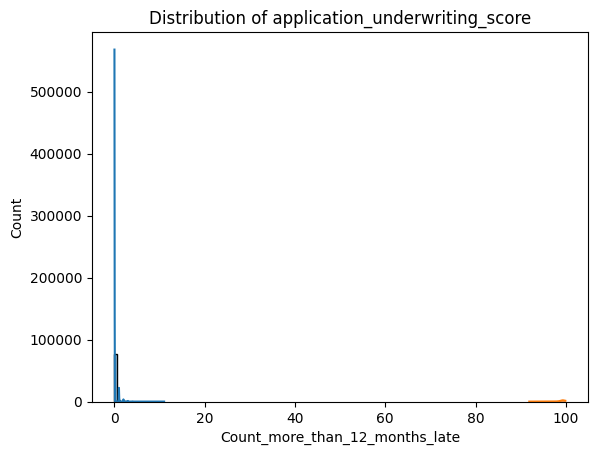

Mode: 99.89, Count: 1972, Percentage: 2.57%
count    76879.000000
mean        99.067291
std          0.739799
min         91.900000
25%         98.810000
50%         99.210000
75%         99.540000
max         99.890000
Name: application_underwriting_score, dtype: float64
Missing values after imputation:
 id                                  0
perc_premium_paid_by_cash_credit    0
age_in_days                         0
Income                              0
Count_3-6_months_late               0
Count_6-12_months_late              0
Count_more_than_12_months_late      0
application_underwriting_score      0
no_of_premiums_paid                 0
sourcing_channel                    0
residence_area_type                 0
premium                             0
renewal                             0
dtype: int64
        perc_premium_paid_by_cash_credit   age_in_days         Income  \
count                       79853.000000  79853.000000   79853.000000   
unique                               NaN

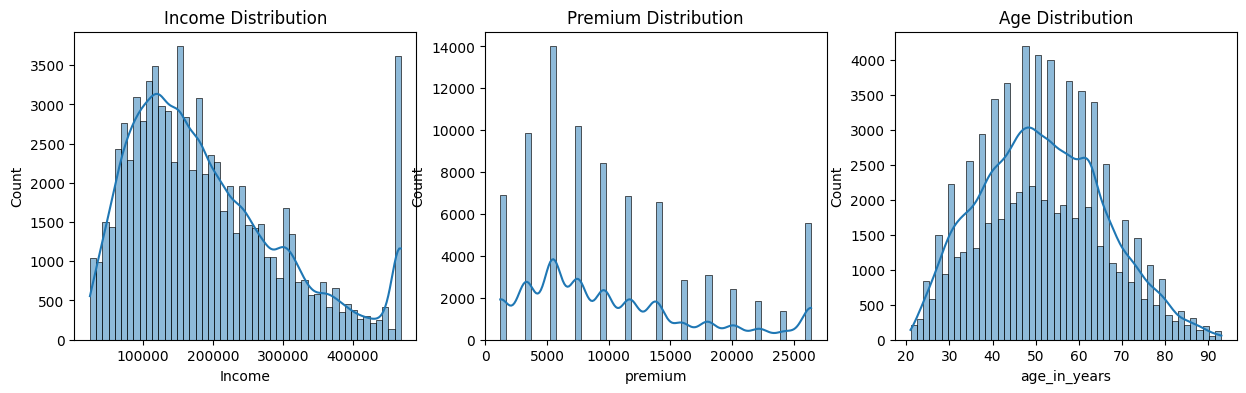

✅ Cleaned dataset saved to ..\data\cleaned_data.csv


In [ ]:
# 01_data_preprocessing.ipynb

# -------------------------------
# Step 1: Import libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import skew

# Set paths
DATA_PATH = Path("../data/train_ZoGVYWq.csv")
OUTPUT_PATH = Path("../data/cleaned_data.csv")

# -------------------------------
# Step 2: Load dataset
# -------------------------------
df = pd.read_csv(DATA_PATH)
print("Shape before preprocessing:", df.shape)
df.head()


# -------------------------------
# Step 3: Missing values handling
# -------------------------------
print("Missing values:\n", df.isnull().sum())

def inspect_column(df_input: pd.DataFrame, columnname: str):
    scores = df_input[columnname].dropna()
    skewness = skew(scores)
    print ("----------------------------------------------------")
    print (f"{columnname}: {skewness}")
    #Plot the skewness
    sns.histplot(scores, kde=True)
    plt.title('Distribution of '+ columnname)
    plt.show()
    # Check for reptitiveness
    mode_value = scores.mode()[0]
    mode_count = (scores == mode_value).sum()
    total_count = len(scores)
    print(f"Mode: {mode_value}, Count: {mode_count}, Percentage: {mode_count / total_count:.2%}")
    print (scores.describe())
    return

inspect_column(df, 'Count_3-6_months_late')
inspect_column(df, 'Count_6-12_months_late')
inspect_column(df, 'Count_more_than_12_months_late')

# Impute late payment counts with 0
for col in ["Count_3-6_months_late", "Count_6-12_months_late", "Count_more_than_12_months_late"]:
    df[col] = df[col].fillna(0)

#Inspect application_underwriting_score for skewness
inspect_column(df, 'application_underwriting_score')

# Impute underwriting score with median (robust to outliers)
df["application_underwriting_score"] = df["application_underwriting_score"].fillna(df["application_underwriting_score"].median())

print("Missing values after imputation:\n", df.isnull().sum())

# -------------------------------
# Step 4: Outlier handling (IQR method)
# -------------------------------
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.where(series < lower, lower,
                    np.where(series > upper, upper, series))

for col in ["Income", "age_in_days", "premium", "no_of_premiums_paid"]:
    df[col] = cap_outliers(df[col])

# -------------------------------
# Step 5: Data formatting
# -------------------------------
# Convert age from days to years
df["age_in_years"] = (df["age_in_days"] / 365).astype(int)

# Drop unneeded columns
df.drop(columns=["id"], inplace=True)

# Reorder columns for clarity
cols = [c for c in df.columns if c != "renewal"] + ["renewal"]
df = df[cols]

# -------------------------------
# Step 6: Quick  checks
# -------------------------------
print(df.describe(include="all"))
print("Shape after preprocessing:", df.shape)

# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Income"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Income Distribution")
sns.histplot(df["premium"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Premium Distribution")
sns.histplot(df["age_in_years"], bins=50, ax=axes[2], kde=True)
axes[2].set_title("Age Distribution")
plt.show()

# -------------------------------
# Step 7: Save cleaned data
# -------------------------------
df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Cleaned dataset saved to {OUTPUT_PATH}")
